In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import dabest
import seaborn as sns
from scipy.stats import bootstrap, ttest_1samp, spearmanr
from scipy import stats
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import ptitprince as pt
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
from p2prev import PCurveMixture

from bids import BIDSLayout
from eeg_positions import get_elec_coords
import mne

# this TFCE implementation can use precomputed null dist
from util.cluster_stats import tfce

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams.update({'font.size': 12})

np.random.seed(0)

In [2]:
if not os.path.exists('figures'):
    os.mkdir('figures')

def savefig(fname):
    fpath = os.path.join('figures', fname)
    plt.savefig(fpath, dpi = 500, bbox_inches = 'tight')

In [3]:
layout = BIDSLayout('bids_dataset', derivatives = True)

/home/johnv/miniforge3/envs/agency-battery/lib/python3.9/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "


In [4]:
def perm_test(layout, attribute, derivative = 'eggOnsetsScores'):
    '''
    performs one-tailed group-level permutation test 
    for specified decoding score attribute against 
    chance performance
    '''
    fs = layout.get(desc = derivative, suffix = 'H0')
    H0 = np.stack([f.get_df()[attribute].to_numpy() for f in fs], axis = 1)
    sub_ps = (H0 >= H0[0, :]).mean(0)
    obs = H0[0, :]
    H0 = H0.mean(1) # average over subjects
    p = (H0 >= H0[0]).mean()
    print('%s = %.03f, p = %.05f'%(attribute, H0[0], p))
    ci = bootstrap([obs], np.mean, confidence_level = 0.95)
    print(ci.confidence_interval)
    return sub_ps
    

for nm in ['audioEnvelope', 'audioOnsets', 'eggEnvelope', 'eggOnsets']:
    print('\n%s decoding score:'%nm)
    perm_test(layout, 'score', '%sScores'%nm)


audioEnvelope decoding score:
score = 0.233, p = 0.00010
ConfidenceInterval(low=0.19948505925430352, high=0.26835536874048305)

audioOnsets decoding score:
score = 0.101, p = 0.00010
ConfidenceInterval(low=0.08612823107419999, high=0.11769805883010463)

eggEnvelope decoding score:
score = 0.349, p = 0.00010
ConfidenceInterval(low=0.3121798898752985, high=0.38251762612313694)

eggOnsets decoding score:
score = 0.136, p = 0.00010
ConfidenceInterval(low=0.12105019579443592, high=0.15222104225323316)


In [5]:
# test for direct effect, i.e. controlling for EMG predictions
sub_ps = perm_test(layout, 'beta_direct')

beta_direct = 0.576, p = 0.00010
ConfidenceInterval(low=0.4813315380036217, high=0.7225807643375499)


In [6]:
# WARNING this p-value is not valid b/c exchangeability assumption
# for the mediator does not hold, but can still get bootstrap CI
_ = perm_test(layout, 'beta_indirect')

beta_indirect = 0.174, p = 0.00010
ConfidenceInterval(low=0.13557016225696428, high=0.21912219510381775)


In [7]:
# fit p-curve mixture model for direct effect prevalence 
model = PCurveMixture(sub_ps, target_accept = .99)
model.fit()
model.summary()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 5 jobs)
NUTS: [effect_size, prevalence]


Sampling 5 chains for 1_000 tune and 1_000 draw iterations (5_000 + 5_000 draws total) took 10 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
effect_size,3.270,0.205,2.898,3.657,0.005,0.003,1801.0,1800.0,1.0
prevalence,0.904,0.060,0.801,1.000,0.001,0.001,1694.0,1199.0,1.0


In [8]:
# assess evidence for heterogenity
model.fit_alternative()
comp = model.compare()
comp # note ranking is in terms of ELPD BEFORE penalty 

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 5 jobs)
NUTS: [effect_size]


Sampling 5 chains for 1_000 tune and 1_000 draw iterations (5_000 + 5_000 draws total) took 5 seconds.


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
mixture,0,153.583835,1.148475,0.000000,1.474169e-16,16.822858,0.000000,False,log
all $H_1$,1,153.201774,0.944731,0.382062,9.461991e-01,17.645209,1.571555,False,log
all $H_0$,2,0.000000,0.000000,153.583835,5.380091e-02,0.000000,16.822858,False,log


In [9]:
# what is best model AFTER penalty?
best_mod = comp.index[np.argmax(comp.weight)]
elpd = comp.elpd_loo[np.argmax(comp.weight)]
print("Bayesian model comparison prefers " + 
      "'%s' model with LOO-ELPD %.02f and weight %.02f"%(best_mod, elpd, comp.weight.max()))

Bayesian model comparison prefers 'all $H_1$' model with LOO-ELPD 153.20 and weight 0.95


In [10]:
# load decoding scores
fs = layout.get(desc = 'eggOnsetsScores', suffix = 'H0')
scr = pd.DataFrame(dict(
    direct = np.stack([f.get_df()['beta_direct'] for f in fs], axis = 1)[0],
    indirect = np.stack([f.get_df()['beta_indirect'] for f in fs], axis = 1)[0],
    total = np.stack([f.get_df()['beta_total'] for f in fs], axis = 1)[0],
    score = np.stack([f.get_df()['score'] for f in fs], axis = 1)[0],
    subject = [f.entities['subject'] for f in fs]
))
scr['prop_direct'] = scr.direct / scr.total
scr['prop_indirect'] = 1 - scr.prop_direct
# and corss-correlations
xcorrs = [f.get_dict() for f in layout.get(suffix = 'xcorr')]
subs = [f.entities['subject'] for f in layout.get(suffix = 'xcorr')]
xcorrs = pd.DataFrame(xcorrs)
xcorrs['subject'] = subs
# then merge
xcorrs = xcorrs.merge(scr, on = 'subject')

xcorrs.head()

,pre->post,post->pre,subject,direct,indirect,total,score,prop_direct,prop_indirect
0,0.000000,-0.007143,01,0.386208,0.042306,0.428513,0.082398,0.901274,0.098726
1,-0.021429,-0.007143,02,1.862691,0.332820,2.195511,0.123678,0.848409,0.151591
2,0.000000,0.000000,03,0.489126,-0.006426,0.482700,0.151377,1.013313,-0.013313
3,0.014286,-0.014286,04,0.571701,0.086069,0.657769,0.153630,0.869151,0.130849
4,0.000000,0.000000,05,0.906106,0.047486,0.953592,0.143152,0.950203,0.049797


In [11]:
def test_correlations(lag_direction):
    print('Score vs. %s lag:'%lag_direction)
    print(spearmanr(xcorrs['score'], xcorrs[lag_direction]))
    print('\nDirect effect vs. %s lag:'%lag_direction)
    print(spearmanr(xcorrs['direct'], xcorrs[lag_direction]))
    print('\nIndirect effect vs. %s lag:'%lag_direction)
    print(spearmanr(xcorrs['indirect'], xcorrs[lag_direction]))
    print('\nProportion direct vs. %s lag:'%lag_direction)
    print(spearmanr(xcorrs['prop_direct'], xcorrs[lag_direction]))

test_correlations('pre->post')

Score vs. pre->post lag:
SpearmanrResult(correlation=0.40995921553856773, pvalue=0.01979059610587903)

Direct effect vs. pre->post lag:
SpearmanrResult(correlation=0.3955022154943865, pvalue=0.025056739871751776)

Indirect effect vs. pre->post lag:
SpearmanrResult(correlation=-0.4461017156490208, pvalue=0.010493606814660073)

Proportion direct vs. pre->post lag:
SpearmanrResult(correlation=0.47997240146681686, pvalue=0.005435483885846024)


In [12]:
test_correlations('post->pre')

Score vs. post->pre lag:
SpearmanrResult(correlation=-0.3498608273917528, pvalue=0.049657130610473214)

Direct effect vs. post->pre lag:
SpearmanrResult(correlation=-0.41279981118867004, pvalue=0.01887221835251595)

Indirect effect vs. post->pre lag:
SpearmanrResult(correlation=0.19161423955950366, pvalue=0.29345036773233246)

Proportion direct vs. post->pre lag:
SpearmanrResult(correlation=-0.36184920525783226, pvalue=0.04184751151266178)


In [13]:
print('Proportion of prediction that is direct (i.e. idependent of EMG):')
print('Mean =', xcorrs.prop_direct.mean())
ci = bootstrap([xcorrs.prop_direct], np.mean, confidence_level = 0.95)
print(ci.confidence_interval)

Proportion of prediction that is direct (i.e. idependent of EMG):
Mean = 0.7450185645726797
ConfidenceInterval(low=0.6575757065387732, high=0.8083014845696268)


In [14]:
_xcorrs = xcorrs.copy()
_xcorrs['lag'] = xcorrs['pre->post']
# so intercept is interpreted as lag w/ no EMG contamination
mod = smf.rlm(formula = 'lag ~ 1 + indirect', data = _xcorrs)
res = mod.fit()
print(res.summary())
print('\n Now the same numbers but with more decimals:\n')
print('\nConfidence interval:')
print(res.conf_int())
print('\np-values:')
print(res.pvalues)

                    Robust linear Model Regression Results                    
Dep. Variable:                    lag   No. Observations:                   32
Model:                            RLM   Df Residuals:                       30
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 13 Mar 2025                                         
Time:                        12:36:05                                         
No. Iterations:                    16                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0036      0.002      2.098      0.0

In [15]:
# now again, aggregating across both pre->post and post->pre lags
_xcorrs['lag'] = (xcorrs['pre->post'] + (-1*xcorrs['post->pre']))/2
# so intercept is interpreted as lag w/ no EMG contamination
mod = smf.rlm(formula = 'lag ~ 1 + indirect', data = _xcorrs)
res = mod.fit()
print(res.summary())
print('\n Now the same numbers but with more decimals:\n')
print('\nConfidence interval:')
print(res.conf_int())
print('\np-values:')
print(res.pvalues)

                    Robust linear Model Regression Results                    
Dep. Variable:                    lag   No. Observations:                   32
Model:                            RLM   Df Residuals:                       30
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 13 Mar 2025                                         
Time:                        12:36:06                                         
No. Iterations:                    17                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0029      0.001      1.975      0.0

In [16]:
# construct mne.Info object with channel positions
evoked = mne.read_evokeds(layout.get(subject = '11', suffix = 'ave')[0].path)[0]
raw = mne.io.read_raw(layout.get(scope = 'PREP', extension = 'fif.gz')[0].path)
coords = get_elec_coords(as_mne_montage = True)
raw = raw.set_montage(coords)
raw = raw.pick(evoked.ch_names)
info = raw.info

Reading /home/johnv/repos/daf/bids_dataset/derivatives/TRF/sub-11/sub-11_task-daf_desc-audioEnvelopeFilters_ave.fif.gz ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms (No comment)
        0 CTF compensation matrices available
        nave = 1 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
No baseline correction applied
Opening raw data file /home/johnv/repos/daf/bids_dataset/derivatives/PREP/sub-01/sub-01_task-daf_desc-PREP_raw.fif.gz...
    Range : 0 ... 976949 =      0.000 ...   976.949 secs
Ready.


In [17]:
before = [mne.read_evokeds(f.path, verbose = False)[0].detrend(1).get_data() for f in layout.get(desc = 'eggOnsetsPatterns')]
before = np.stack(before).transpose(0, 2, 1)
after = [mne.read_evokeds(f.path, verbose = False)[0].detrend(1).get_data() for f in layout.get(desc = 'eggOnsetsPatternsPost')]
after = np.stack(after).transpose(0, 2, 1)
adj, _ = mne.channels.find_ch_adjacency(info, 'eeg')

alpha = .05
thres = stats.t.ppf(1.0 - 2*alpha, after.shape[0] - 1)
print('Using thres = %.03f'%thres)

tval, clusts, pval, H0 = mne.stats.permutation_cluster_1samp_test(
    after - before, 
    threshold = thres, 
    adjacency = adj, 
    tail = 0,
    seed = 0,
    n_permutations = 10000,
    n_jobs = -1,
    out_type = 'mask'
)
clusts = np.stack(clusts)
print('Found %d clusters! p = %.03f'%((pval <= alpha).sum(), pval.min()))
if pval.min() <= alpha:
    clust = np.any(clusts[pval <= .05], 0)
else:
    clust = np.zeros_like(clusts[0])

print('p =', np.min(pval))

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 60
Using thres = 1.309
stat_fun(H1): min=-5.320955 max=3.766352
Running initial clustering
Found 52 clusters
Permuting 9999 times...


  0%|          |  : 0/9999 [00:00<?,       ?it/s]

/home/johnv/.local/lib/python3.9/site-packages/mne/datasets/eegbci/eegbci.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/johnv/.local/lib/python3.9/site-packages/mne/datasets/eegbci/eegbci.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/johnv/.local/lib/python3.9/site-packages/mne/datasets/eegbci/eegbci.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/johnv/.local/lib/python3.9/site-packages/mne/datasets/eegbci/eegbci.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/johnv/.local/lib/python3.9/site-packages/mne/datasets/eegbci/eegbci.py:8: DeprecationWarning: pkg_resource

Computing cluster p-values
Done.
Found 1 clusters! p = 0.004
p = 0.0039


In [18]:
# try something not dependent on a clustering threshold as well
X = (after - before).reshape(after.shape[0], after.shape[1] * after.shape[2])
tvals, pvals, H0 = mne.stats.permutation_t_test(X)
print(tvals.max(), pvals.min())

Permuting 9999 times...
3.766352339944259 0.0155


In [19]:
pats_before = [mne.read_evokeds(f.path, verbose = False)[0] for f in layout.get(desc = 'eggOnsetsPatterns')]
pat_before = mne.grand_average(pats_before).detrend(1)
pats_after = [mne.read_evokeds(f.path, verbose = False)[0] for f in layout.get(desc = 'eggOnsetsPatternsPost')]
pat_after = mne.grand_average(pats_after).detrend(1)
diff = mne.combine_evoked([pat_after, pat_before], weights=[1, -1])
diff.nave = None

Identifying common channels ...
Identifying common channels ...


tmin, tmax:  -0.3142857142857143 0.11428571428571432


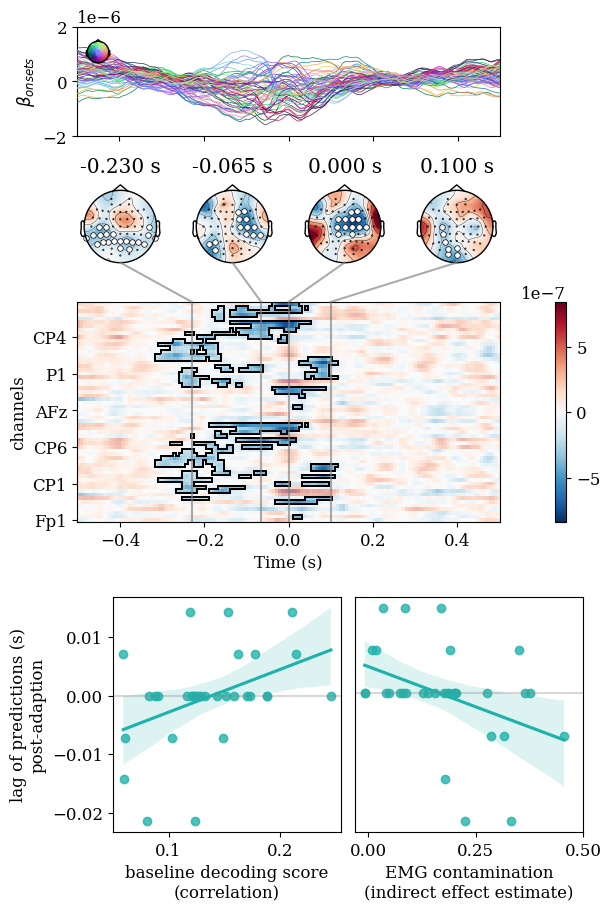

In [20]:
from mne.viz.utils import _connection_line

def add_label(ax, label, x_offset = -.19, y_offset = .0):
    xmin, xmax = ax.get_xlim()
    xscale = xmax - xmin
    ymin, ymax = ax.get_ylim()
    yscale = ymax - ymin
    ax.text(
        xmin + x_offset*xscale, ymax + yscale*y_offset, 
        label, size = 25, weight = 'bold'
    )


effect = diff.copy()
info = mne.create_info(effect.ch_names, effect.info['sfreq'], ch_types = 'eeg')
effect.info = info
effect.nave = None
coords = get_elec_coords(as_mne_montage = True)
effect = effect.set_montage(coords)
effect.set_montage(coords)

def _prepare_joint_axes(n_maps, figsize=None):
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = GridSpec(5, n_maps, height_ratios=[1, 1, 2, 1, 2], figure=fig)
    evo_ax = fig.add_subplot(gs[0, :n_maps])
    map_ax = [fig.add_subplot(gs[1, x]) for x in range(n_maps)]  # 2nd row
    main_ax = fig.add_subplot(gs[2, :n_maps])  # 3rd row

    gs = GridSpec(5, 2, height_ratios=[1, 1, 2, 1, 2], hspace = 0., figure = fig)
    ax0 = fig.add_subplot(gs[-1, 0])
    ax1 = fig.add_subplot(gs[-1, 1])
    
    return fig, main_ax, map_ax, evo_ax, ax0, ax1


# prepare axes
times = [-.23, -.065, 0, .1]
fig, main_ax, map_axs, evo_ax, ax0, ax1 = _prepare_joint_axes(len(times), figsize = (6, 9))

pat_after.nave = None
pat_after.info = info
pat_after.detrend(1).plot(
    axes = evo_ax, 
    spatial_colors = True, 
    scalings = 1.,
    show = False
)
evo_ax.set_title('')
evo_ax.xaxis.set_ticklabels([])
evo_ax.set_xlabel('')
evo_ax.set_ylabel(r'$\beta_{%s}$'%('onsets'))
evo_ax.set_ylim(-2e-6, 2e-6)

# plot effect map
effect.plot_image(
    mask = clust.T, 
    mask_alpha = .5, 
    mask_cmap = 'RdBu_r', # same as unmasked
    show_names = True,
    colorbar = True,
    axes = main_ax,
    scalings = 1.,
    show = False
)
main_ax.set_ylabel('channels')
main_ax.set_title('')
vmin, vmax = main_ax.images[0].get_clim() # remember color limits

cb = main_ax.images[-1].colorbar
cb.ax.set_title('')

# plot topomaps for midpoints of clusters
effect.plot_topomap(times = times, axes = map_axs, 
                    mask = clust.T, 
                    mask_params = {'markersize': 8},
                    vmin = vmin,
                    vmax = vmax, # enforce same color limits as main
                    colorbar = False,
                    show = False,
                    scalings = 1.
                   )

# draw connecting lines
lines = [_connection_line(timepoint, fig, main_ax, map_ax_)
             for timepoint, map_ax_ in zip(times, map_axs)]
for line in lines:
    fig.lines.append(line)
for timepoint in times:
    main_ax.axvline(timepoint, color = 'grey', linestyle = '-',
                      linewidth = 1.5, alpha = .66)

np.random.seed(0)
reg_kwargs = dict(data = xcorrs, ci = 95)
ax0.set_xticks([0., .1, .2, .3])
ax0.axhline(0, color = 'gray', alpha = .3)
sns.regplot(x = 'score', y = 'pre->post', color = 'lightseagreen', ax = ax0, **reg_kwargs)
#sns.regplot(x = 'score', y = 'post->pre', color = 'darkseagreen', ax = ax0, **reg_kwargs)
ax0.set_ylabel('lag of predictions (s)\npost-adaption')
ax0.set_xlabel('baseline decoding score\n(correlation)')
sns.regplot(x = 'indirect', y = 'pre->post', color = 'lightseagreen', ax = ax1, **reg_kwargs)
#sns.regplot(x = 'indirect', y = 'post->pre', color = 'darkseagreen', ax = ax1, **reg_kwargs)
ax1.set_ylabel(None)
ax1.set_yticks([])
ax1.axhline(0, color = 'gray', alpha = .3)
ax1.set_xticks([0, .25, .5])
ax1.set_xlabel('EMG contamination\n(indirect effect estimate)')
#legend_elements = [
#    Line2D([0], [0], color = 'lightseagreen', lw = 4, label = r'pre$\rightarrow$post'),
#    Line2D([0], [0], color = 'darkseagreen', lw = 4, label = r'post$\rightarrow$pre'),
#]
#ax0.legend(handles = legend_elements, loc = 'upper left')
    
# show final plot
sig_times = effect.times[np.any(clust, -1)]
print('tmin, tmax: ', sig_times.min(), sig_times.max())

savefig('difference.png')
plt.show()

In [21]:
def plot_topo(scr, p, vlim, ax):
    max_delta = np.abs(scr).max()
    return mne.viz.plot_topomap(
        scr,
        pos = info,
        mask = p < .05,
        axes = ax,
        show = False,
        vmin = -vlim,
        vmax = vlim
    )

In [22]:
def load_encoding_scores(desc):
    '''
    Arguments
    ----------
    desc : str
        BIDS desc-xxx field for encoding model you want to load
        
    Returns
    ------
    observed : an (n_subjects, n_channels) np.array
        Observed correlations between encoding
        model predictions and actual EEG.
    H0 : an (n_permutations, n_channels) np.array
        The group-level t-statistic comparing correlations 
        to chance for each EEG channel, on each permutation.
        The first permutation is the observed values. 
    '''
    # load permutation null distribution for each subject
    fs = layout.get(desc = desc, suffix = 'score')
    H0 = np.stack([np.load(f.path) for f in fs], axis = 0)
    # pull out observed value from null
    obs = H0[:, 0, :]
    # Fisher's Z-transform
    H0 = np.arctanh(H0) # Fisher's Z-tranform 
    # compute group-level t-statistic for each permutaiton
    H0_t = H0.mean(0) / (H0.std(0)/np.sqrt(H0.shape[0]))
    # convert average back to correlation scale for observed value
    return obs, H0_t

adj, _ = mne.channels.find_ch_adjacency(info, 'eeg')
scores_w, H0 = load_encoding_scores('encodingWithEGGOnsets')
stat, p_w = tfce(H0, adj, start = 0, step = .2)
print('TFCE = %.3f, p = %.05f'%(stat, p_w.min()))

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 60


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed:    0.7s
[Parallel(n_jobs=6)]: Done 342 tasks      | elapsed:    2.8s
[Parallel(n_jobs=6)]: Done 1062 tasks      | elapsed:    7.3s
[Parallel(n_jobs=6)]: Done 2070 tasks      | elapsed:   13.4s
[Parallel(n_jobs=6)]: Done 3366 tasks      | elapsed:   21.4s
[Parallel(n_jobs=6)]: Done 4950 tasks      | elapsed:   31.1s
[Parallel(n_jobs=6)]: Done 6822 tasks      | elapsed:   44.0s
[Parallel(n_jobs=6)]: Done 8982 tasks      | elapsed:   58.3s


TFCE = 11.339, p = 0.00010


[Parallel(n_jobs=6)]: Done 10000 out of 10000 | elapsed:  1.1min finished


In [23]:
scores_wo, H0 = load_encoding_scores('encodingWithoutEGGOnsets')
stat, p_wo = tfce(H0, adj, start = 0, step = .2)
print('TFCE = %.3f, p = %.05f'%(stat, p_wo.min()))

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 426 tasks      | elapsed:    2.7s
[Parallel(n_jobs=6)]: Done 1146 tasks      | elapsed:    7.2s
[Parallel(n_jobs=6)]: Done 2154 tasks      | elapsed:   13.4s
[Parallel(n_jobs=6)]: Done 3450 tasks      | elapsed:   21.3s
[Parallel(n_jobs=6)]: Done 5034 tasks      | elapsed:   30.9s
[Parallel(n_jobs=6)]: Done 6906 tasks      | elapsed:   42.2s
[Parallel(n_jobs=6)]: Done 9066 tasks      | elapsed:   55.6s


TFCE = 10.117, p = 0.00010


[Parallel(n_jobs=6)]: Done 10000 out of 10000 | elapsed:  1.0min finished


In [24]:
# get absolute difference for plotting
scores = scores_w - scores_wo
# get difference on Z-scale for stats
scores_Z = np.arctanh(scores_w) - np.arctanh(scores_wo)
t, _, p, _ = mne.stats.permutation_cluster_1samp_test(
    scores_Z, 
    threshold = dict(start = 0, step = .2), 
    adjacency = adj, 
    tail = 1,
    seed = 0,
    n_permutations = H0.shape[0],
    n_jobs = -1
)

chs = np.array(info.ch_names)[p < .05]
ps = p[p < .05]
for ch, _p in zip(chs, ps):
    print('%s: p = %.04f'%(ch, _p))
corrs_w, corrs_wo, corrs = scores_w, scores_wo, scores # rename for later
print('TFCE = %.3f, p = %.05f'%(t.max(), p.min()))

stat_fun(H1): min=-0.503902 max=3.222966
Running initial clustering
Using 17 thresholds from 0.00 to 3.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 60 clusters
Permuting 9999 times...


  0%|          |  : 0/9999 [00:00<?,       ?it/s]

Computing cluster p-values
Done.
FC1: p = 0.0275
C3: p = 0.0373
T7: p = 0.0206
TP9: p = 0.0177
CP5: p = 0.0373
Pz: p = 0.0361
P7: p = 0.0373
O1: p = 0.0271
P8: p = 0.0396
FC3: p = 0.0316
C5: p = 0.0127
TP7: p = 0.0373
P5: p = 0.0206
PO7: p = 0.0085
PO8: p = 0.0234
P6: p = 0.0459
FT8: p = 0.0462
TFCE = 2.377, p = 0.00850


In [25]:
scores_w = [np.load(f.path)[0] for f in layout.get(desc = 'encodingWithEGGOnsets', suffix = 'score')]
scores_w = pd.DataFrame(np.stack(scores_w), columns = evoked.ch_names)
scores_w['model'] = 'with EGG onsets'
scores_w['subject'] = layout.get_subjects()

scores_wo = [np.load(f.path)[0] for f in layout.get(desc = 'encodingWithoutEGGOnsets', suffix = 'score')]
scores_wo = pd.DataFrame(np.stack(scores_wo), columns = evoked.ch_names)
scores_wo['model'] = 'without EGG onsets'
scores_wo['subject'] = layout.get_subjects()

scores = pd.concat([scores_wo, scores_w])

new_scores = []
chs = ['C5', 'Pz'] # to plot
for ch in chs:
    scores_ch = scores[['subject', 'model', ch]]
    scores_ch['channel'] = ch
    scores_ch = scores_ch.rename(columns = {ch: 'correlation'})
    new_scores.append(scores_ch)
scores = pd.concat(new_scores)
scores.head()

/tmp/ipykernel_1626953/1077796318.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores_ch['channel'] = ch
/tmp/ipykernel_1626953/1077796318.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores_ch['channel'] = ch


,subject,model,correlation,channel
0,01,without EGG onsets,0.039718,C5
1,02,without EGG onsets,0.034663,C5
2,03,without EGG onsets,0.018477,C5
3,04,without EGG onsets,0.097383,C5
4,05,without EGG onsets,0.077098,C5


In [26]:
def calc_ci(x):
    ci = bootstrap([x], np.mean, random_state = 0, confidence_level = .95)
    ci = ci.confidence_interval
    m = np.mean(x)
    return m, ci

def plot_corrs(df, ax):
    data = dabest.load(
        data = df, 
        x = 'model', y = 'correlation', 
        idx = ('without EGG onsets', 'with EGG onsets'),
        id_col = 'subject',
        paired = 'baseline',
        random_seed = 0
    )
    data.mean_diff.plot(ax = ax, es_marker_size = 5)
    m, ci = calc_ci(df[df.model == 'without EGG onsets'].correlation)
    ax.vlines(0, ci[0], ci[1], color = 'black')
    ax.scatter(0, m, color = 'black')
    m, ci = calc_ci(df[df.model == 'with EGG onsets'].correlation)
    ax.vlines(1, ci[0], ci[1], color = 'black')
    ax.scatter(1, m, color = 'black')


In [27]:
scr = pd.DataFrame([f.get_dict() for f in layout.get(desc = 'decoding', suffix = 'score')])
dfs = []
for col in scr.columns:
    df = pd.DataFrame({'out-of-sample correlation': scr[col].to_numpy(), 'feature': col})
    dfs.append(df)
df = pd.concat(dfs)
df.feature = df.feature.replace(dict(
    audioEnvelope = 'audio envelope',
    audioOnsets = 'audio onsets',
    eggEnvelope = 'EGG envelope',
    eggOnsets = 'EGG onsets'
))
df.head()

,out-of-sample correlation,feature
0,0.172989,audio envelope
1,0.247645,audio envelope
2,0.191360,audio envelope
3,0.484807,audio envelope
4,0.323221,audio envelope


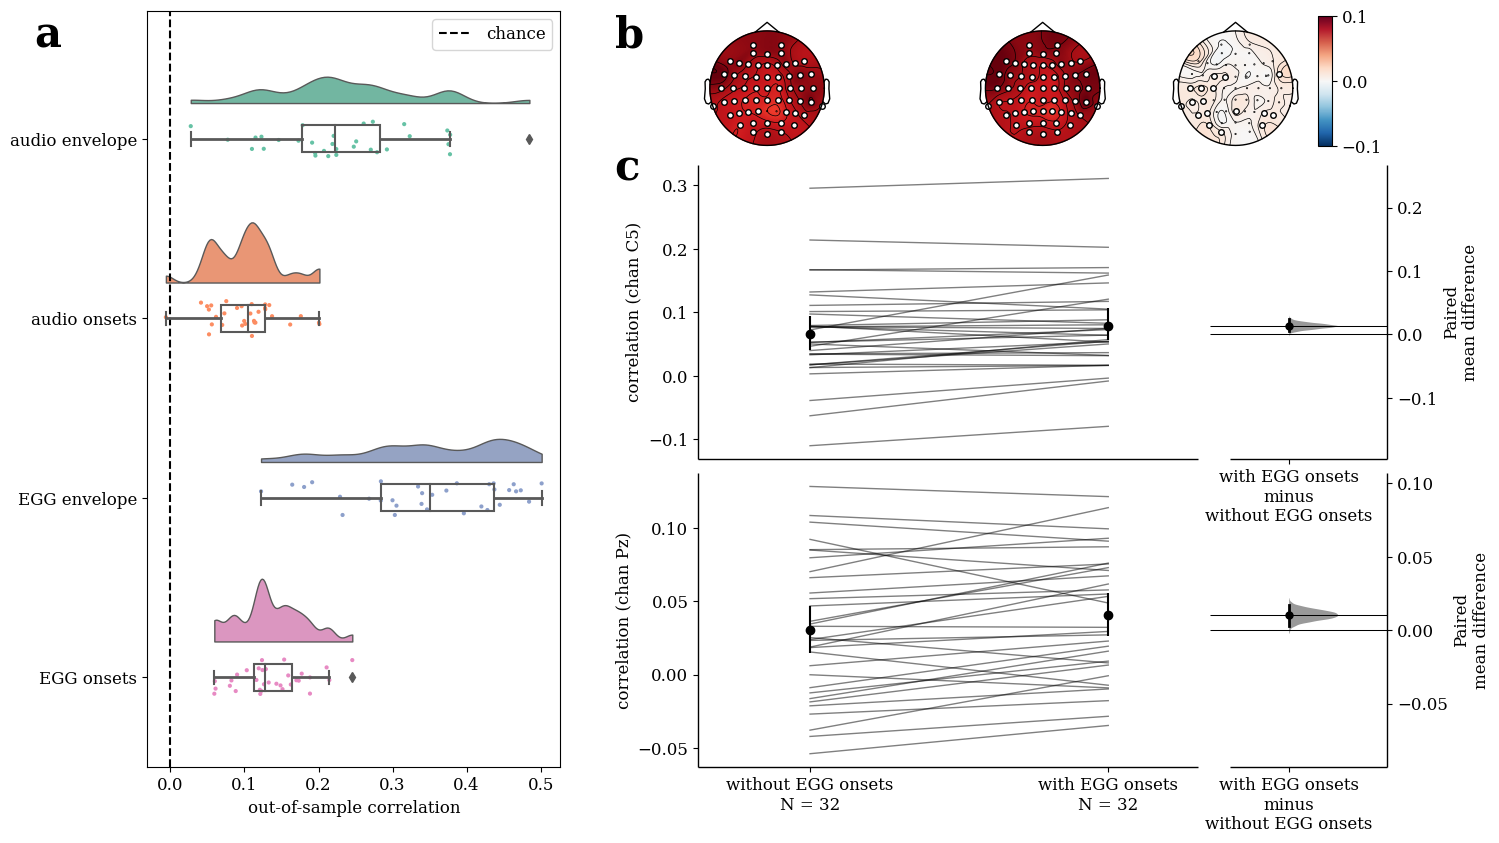

In [28]:
def add_label(ax, label, x_offset = -.17, y_offset = .1):
    xmin, xmax = ax.get_xlim()
    xscale = xmax - xmin
    ymin, ymax = ax.get_ylim()
    yscale = ymax - ymin
    ax.text(
        xmin + x_offset*xscale, ymax + yscale*y_offset, 
        label, size = 30, weight = 'bold'
    )

fig = plt.figure(figsize = (16, 9))
gs = gridspec.GridSpec(5, 5, wspace = 1, hspace = .1)

vlim = np.max([corrs_wo.mean(0).max(), corrs_w.mean(0).max(), corrs.mean(0).max()])
ax = fig.add_subplot(gs[0, 2])
plot_topo(corrs_wo.mean(0), p_wo, vlim, ax)
ax = fig.add_subplot(gs[0, 3])
plot_topo(corrs_w.mean(0), p_w, vlim, ax)
ax = ax.inset_axes([1.4, 0, 1, 1])
img = plot_topo(np.mean(corrs, 0), p, vlim, ax)
cax = ax.inset_axes([1.1, 0, .1, 1])
plt.colorbar(img[0], cax)

axs = [fig.add_subplot(gs[1:3, 2:]), fig.add_subplot(gs[3:, 2:])]
for i, ch in enumerate(chs):
    scr = scores[scores.channel == ch]
    plot_corrs(scr, axs[i])
    axs[i].set_ylabel('correlation (chan %s)'%ch)
    if i < len(chs) - 1:
        axs[i].set_xticks([])
        
add_label(axs[0], 'c', y_offset = -.05)
add_label(axs[0], 'b', y_offset = .4)
add_label(axs[0], 'a', y_offset = .4, x_offset = -1.35)

ax = fig.add_subplot(gs[:, :2])
pt.RainCloud(x = 'feature', y = 'out-of-sample correlation', data = df, orient = 'h', ax = ax)
ax.axvline(0, color = 'black', linestyle = '--', label = 'chance')
ax.set_ylabel(None)
ax.legend()


savefig('scores.jpeg')
plt.show()

In [29]:
def add_label(ax, label, x_offset = -.17, y_offset = .1):
    xmin, xmax = ax.get_xlim()
    xscale = xmax - xmin
    ymin, ymax = ax.get_ylim()
    yscale = ymax - ymin
    ax.text(
        xmin + x_offset*xscale, ymax + yscale*y_offset, 
        label, size = 25, weight = 'bold'
    )

def get_patterns(mod, tp):
    tp = tp[0].upper() + tp[1:]
    evokeds_pat = [mne.read_evokeds(f.path)[0] for f in layout.get(desc = '%s%sPatterns'%(mod, tp))]
    evo = mne.grand_average(evokeds_pat)
    patterns = evokeds_pat
    t = evokeds_pat[0].times
    patterns = [p.detrend(1) for p in patterns]
    patterns = np.stack([p.get_data() for p in patterns])
    orig_shape = patterns.shape
    new_shape = (patterns.shape[0], patterns.shape[1] * patterns.shape[2])
    patterns = patterns.reshape(new_shape)
    t, p, _ = mne.stats.permutation_t_test(patterns)
    t = t.reshape(orig_shape[1:])
    p = p.reshape(orig_shape[1:])
    return evo, p

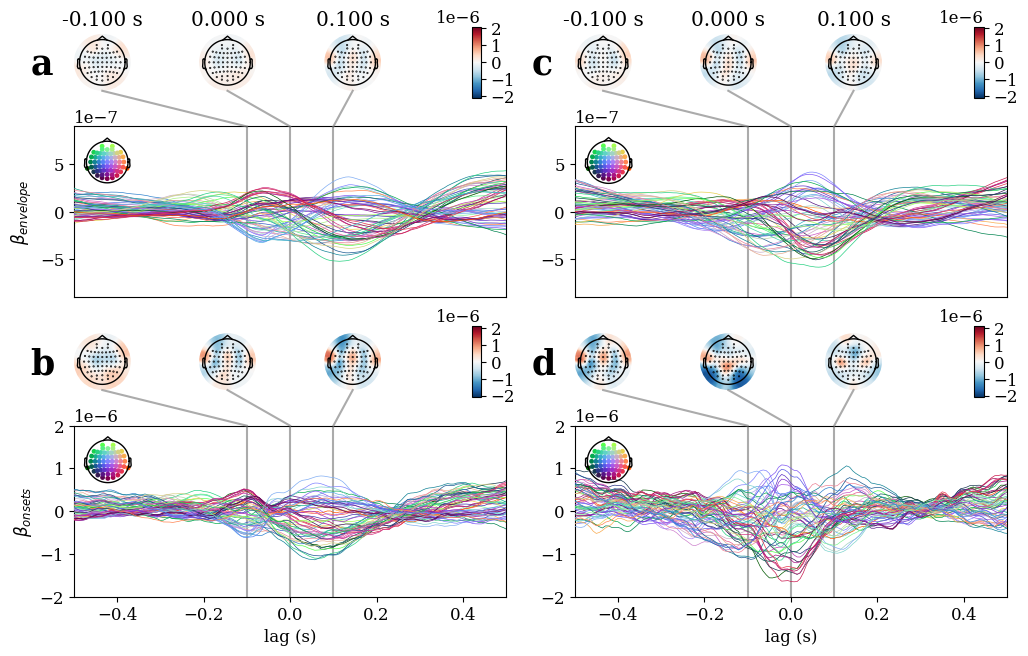

In [30]:
def plot_patterns(mod, tp, ts_ax, topo_axs):
    patterns, _ = get_patterns(mod, tp)
    info = mne.create_info(patterns.ch_names, patterns.info['sfreq'], ch_types = 'eeg')
    patterns.info = info
    patterns.nave = None
    coords = get_elec_coords(as_mne_montage = True)
    patterns = patterns.set_montage(coords)
    if tp == 'envelope':
        ts_ax.set_ylim(-.9e-6, .9e-6)
    else:
        ts_ax.set_ylim(-2e-6, 2e-6)
    ts_args = dict(scalings = 1., units = r'$\beta_{%s}$'%tp, ylim = (-2e-6, 2e-6), axes = ts_ax)
    topo_args = dict(scalings = 1., vmin = -2.1e-6, vmax = 2.1e-6, contours = 0, axes = topo_axs)
    patterns.detrend(1).plot_joint(
        ts_args = ts_args, topomap_args = topo_args, 
        title = None, times = [-.1, 0, .1],
        show = False
    )
    ts_ax.set_xlabel('lag (s)')
    if tp == 'onsets':
        for ax in topo_axs[:-1]:
            ax.set_title('')
    else:
        ts_ax.set_xticks([])
        ts_ax.set_xlabel('')
    if mod == 'egg':
        ts_ax.set_ylabel('')

hspace = .4

fig = plt.figure(figsize = (10, 6))
gs = gridspec.GridSpec(6, 2*4, wspace = 1.2, hspace = hspace)
ts_ax = fig.add_subplot(gs[1:3, :4])
topo_axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
gs = gridspec.GridSpec(6, 2*40, wspace = .25, hspace = hspace)
topo_axs += [fig.add_subplot(gs[0, 34])] # smaller axis for colorbar
plot_patterns('audio', 'envelope', ts_ax, topo_axs)
add_label(ts_ax, 'a', x_offset = -.1, y_offset = .3)

gs = gridspec.GridSpec(6, 2*4, wspace = 1.2, hspace = hspace)
ts_ax = fig.add_subplot(gs[4:, :4])
topo_axs = [fig.add_subplot(gs[3, i]) for i in range(3)]
gs = gridspec.GridSpec(6, 2*40, wspace = .25, hspace = hspace)
topo_axs += [fig.add_subplot(gs[3, 34])] # smaller axis for colorbar
plot_patterns('audio', 'onsets', ts_ax, topo_axs)
add_label(ts_ax, 'b', x_offset = -.1, y_offset = .3)

gs = gridspec.GridSpec(6, 2*4, wspace = 1.2, hspace = hspace)
ts_ax = fig.add_subplot(gs[1:3, 4:])
topo_axs = [fig.add_subplot(gs[0, i]) for i in range(4, 7)]
gs = gridspec.GridSpec(6, 2*40, wspace = .25, hspace = hspace)
topo_axs += [fig.add_subplot(gs[0, -3])] # smaller axis for colorbar
plot_patterns('egg', 'envelope', ts_ax, topo_axs)
add_label(ts_ax, 'c', x_offset = -.1, y_offset = .3)

gs = gridspec.GridSpec(6, 2*4, wspace = 1.2, hspace = hspace)
ts_ax = fig.add_subplot(gs[4:, 4:])
topo_axs = [fig.add_subplot(gs[3, i]) for i in range(4, 7)]
gs = gridspec.GridSpec(6, 2*40, wspace = .25, hspace = hspace)
topo_axs += [fig.add_subplot(gs[3, -3])] # smaller axis for colorbar
plot_patterns('egg', 'onsets', ts_ax, topo_axs)
add_label(ts_ax, 'd', x_offset = -.1, y_offset = .3)

savefig('TRFs.jpeg')
plt.show()

In [31]:
f = layout.get(scope = 'clean', extension = 'fif.gz')[10]
epochs = mne.read_epochs(f.path, preload = True)
epochs = epochs.filter(70, None, picks = ['audio', 'egg']) # smooth for visualization only 
epochs = epochs.filter(None, 30, picks = ['audio_envelope', 'egg_envelope', 'audio_onsets', 'egg_onsets'])

He wrote his name boldly at the top of the sheet.
He wrote his name boldly at the top of the sheet.


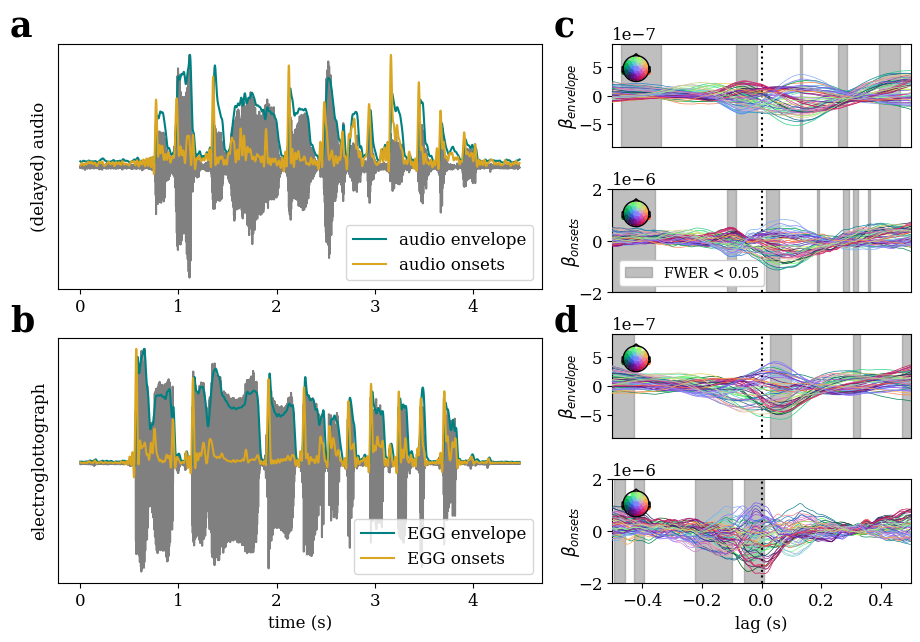

In [32]:
def plot_envelope(mod, ax):
    trial = 20
    X = epochs['adaption'][trial].get_data(picks = ['%s'%mod, '%s_envelope'%mod, '%s_onsets'%mod])
    X = np.squeeze(X)
    if mod == 'egg':
        mod = 'EGG'
    ax.plot(epochs.times, X[0], color = 'grey')
    ax.plot(
        epochs.times, X[1] * (X[0].max()/X[1].max()), 
        label = '%s envelope'%mod,
        color = 'teal'
    )
    ax.plot(
        epochs.times, X[2] * (X[0].max()/X[2].max()), 
        label = '%s onsets'%mod,
        color = 'goldenrod'
    )
    ax.set_xlabel('time (s)')
    if mod == 'audio':
        mod = '(delayed) ' + mod
        ax.set_xlabel('')
    else:
        mod = 'electroglottograph'
    ax.set_ylabel(mod)
    ax.legend()
    ax.get_yaxis().set_ticks([])
    sent = epochs['adaption'][trial].metadata.sentence.iloc[0]
    print(sent)

def plot_patterns(mod, tp, ts_ax):
    patterns, p = get_patterns(mod, tp)
    info = mne.create_info(patterns.ch_names, patterns.info['sfreq'], ch_types = 'eeg')
    patterns.info = info
    patterns.nave = None
    coords = get_elec_coords(as_mne_montage = True)
    patterns = patterns.set_montage(coords)
    if tp == 'envelope':
        ts_ax.set_ylim(-.9e-6, .9e-6)
    else:
        ts_ax.set_ylim(-2e-6, 2e-6)
    ts_args = dict(scalings = 1., axes = ts_ax)
    patterns.detrend(1).plot(
        spatial_colors = True,
        show = False, **ts_args
    )
    ts_ax.set_xlabel('lag (s)')
    ts_ax.set_ylabel(r'$\beta_{%s}$'%tp)
    if (tp == 'onsets') and (mod == 'egg'):
        ts_ax.set_xlabel('lag (s)')
    else:
        ts_ax.set_xlabel('')
        ts_ax.set_xticks([])
    ts_ax.set_title('')
    ts_ax.yaxis.set_label_coords(-.1, .5)
    from mne.stats.cluster_level import _find_clusters
    times = patterns.times
    clusters_1d, _ = _find_clusters(p.min(0), threshold = .05, tail = -1)
    for i, clust in enumerate(clusters_1d):
        tmin = times[clust][0]
        tmax = times[clust][-1]
        if (i == 0) and (tp == 'onsets') and (mod == 'audio'):
            ax.axvspan(tmin, tmax, alpha = .5, color = 'grey', zorder = 0, label = 'FWER < 0.05')
            ax.legend(loc = 'lower left', framealpha = 1, fontsize = 'small')
        else:
            ax.axvspan(tmin, tmax, alpha = .5, color = 'grey', zorder = 0)
    ax.axvline(0, color = 'black', linestyle = 'dotted')


fig = plt.figure(figsize = (11, 7))
gs = gridspec.GridSpec(2, 5, wspace = .62, hspace = .2)
ax = fig.add_subplot(gs[0, :3])
plot_envelope('audio', ax)
add_label(ax, 'a', x_offset = -.1, y_offset = .03)
add_label(ax, 'c', x_offset = 1.025, y_offset = .03)
ax = fig.add_subplot(gs[1, :3])
plot_envelope('egg', ax)
add_label(ax, 'b', x_offset = -.1, y_offset = .03)
add_label(ax, 'd', x_offset = 1.025, y_offset = .03)

gs = gridspec.GridSpec(4, 5, wspace = .62, hspace = .4)
ax = fig.add_subplot(gs[0, 3:])
plot_patterns('audio', 'envelope', ax)
ax = fig.add_subplot(gs[1, 3:])
plot_patterns('audio', 'onsets', ax)
ax = fig.add_subplot(gs[2, 3:])
plot_patterns('egg', 'envelope', ax)
ax = fig.add_subplot(gs[3, 3:])
plot_patterns('egg', 'onsets', ax)

savefig('features.jpeg')
plt.show()